<a href="https://colab.research.google.com/github/zhassanofficial/Deep-Learning/blob/master/vanishing_gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential

In [31]:
X,y = make_moons(n_samples=250, noise=0.05, random_state=42)

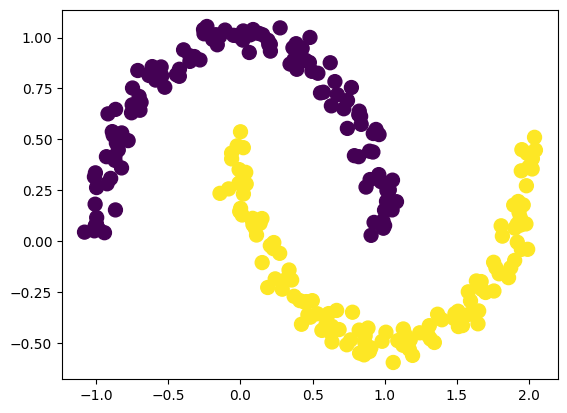

In [32]:
plt.scatter(X[:,0],X[:,1], c=y, s=100)
plt.show()

In [33]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

In [34]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [35]:
model.get_weights()[0]

array([[-0.30152714,  0.3550337 , -0.52881956,  0.2433601 ,  0.33459288,
         0.06646425, -0.0408172 ,  0.6248495 , -0.412561  , -0.11467195],
       [ 0.0242914 ,  0.0449717 ,  0.45727295, -0.67347544, -0.6261113 ,
        -0.15958637, -0.25295848, -0.2850258 ,  0.41229695,  0.31420594]],
      dtype=float32)

In [36]:
old_weights = model.get_weights()[0]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [38]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5100 - loss: 0.6931
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5100 - loss: 0.6920
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5100 - loss: 0.6916 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6913 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6909 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6907 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6905 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6900 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5100 - loss: 0.6895 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6891 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6887 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5100 - loss

In [39]:
new_weights = model.get_weights()[0]

In [40]:
model.optimizer.get_config()["learning_rate"]

0.0010000000474974513

In [41]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [42]:
gradient

array([[  376.17358,  -250.26016,   305.8307 ,  -361.79327,  -340.04663,
         -445.95126,  -538.5848 ,  -242.3942 ,   300.17642,   424.2652 ],
       [-1018.94086,   975.32166, -1080.6014 ,  1051.9893 ,  1047.2273 ,
         1062.3945 ,  1149.2362 ,  1021.5332 ,  -957.00085, -1082.1082 ]],
      dtype=float32)

In [43]:
percent_change

array([[ 124.75614 ,   70.489136,   57.832718,  148.66582 ,  101.629974,
         670.9642  , 1319.5045  ,   38.792416,   72.759285,  369.9817  ],
       [4194.6577  , 2168.7454  ,  236.31432 ,  156.20306 ,  167.25897 ,
         665.71765 ,  454.3181  ,  358.40027 ,  232.11447 ,  344.39456 ]],
      dtype=float32)

In [44]:
old_weights

array([[-0.30152714,  0.3550337 , -0.52881956,  0.2433601 ,  0.33459288,
         0.06646425, -0.0408172 ,  0.6248495 , -0.412561  , -0.11467195],
       [ 0.0242914 ,  0.0449717 ,  0.45727295, -0.67347544, -0.6261113 ,
        -0.15958637, -0.25295848, -0.2850258 ,  0.41229695,  0.31420594]],
      dtype=float32)

In [45]:
new_weights

array([[-0.67770076,  0.60529387, -0.8346503 ,  0.6051534 ,  0.6746395 ,
         0.5124155 ,  0.4977676 ,  0.8672437 , -0.71273744, -0.53893715],
       [ 1.0432323 , -0.93035   ,  1.5378745 , -1.7254647 , -1.6733387 ,
        -1.221981  , -1.4021947 , -1.3065591 ,  1.3692979 ,  1.3963143 ]],
      dtype=float32)

In [46]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [47]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [48]:
old_weights = model.get_weights()[0]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [50]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5100 - loss: 0.6938
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6911 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6883 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5100 - loss: 0.6836 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5450 - loss: 0.6761 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7000 - loss: 0.6643 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7450 - loss: 0.6484 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7900 - loss: 0.6271 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8250 - loss: 0.5997 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8450 - loss: 0.5688 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8500 - loss: 0.5387 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8650 - loss

In [51]:
new_weights = model.get_weights()[0]

In [52]:
model.optimizer.get_config()["learning_rate"]

0.0010000000474974513

In [53]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [54]:
gradient

array([[ 79.610214 , -77.85439  , 180.1384   , -12.598931 ,  -2.7377305,
        -17.420172 , -31.733925 , -72.29328  , -85.36738  , 111.742905 ],
       [-63.83824  , -91.21728  , -90.41003  ,  11.86186  , -43.078182 ,
         39.01559  , 282.8248   ,  -1.8893479,  77.68783  , -78.24781  ]],
      dtype=float32)

In [55]:
percent_change

array([[5.6199852e+01, 3.1025501e+01, 2.9217415e+01, 2.4441736e+00,
        7.4463850e-01, 2.7900915e+00, 7.6977460e+02, 3.3152466e+01,
        2.1207191e+01, 1.7129936e+01],
       [9.7580414e+01, 1.6945398e+01, 4.8437565e+01, 2.2249064e+00,
        7.3524280e+00, 1.2961345e+01, 4.1822918e+01, 2.8528267e-01,
        1.5650231e+01, 1.9823349e+01]], dtype=float32)

In [56]:
old_weights

array([[ 0.14165556, -0.25093678, -0.61654466,  0.51546794,  0.36765903,
         0.6243585 , -0.0041225 ,  0.21806306,  0.4025398 , -0.65232533],
       [ 0.06542116,  0.53830117, -0.18665272,  0.53313977,  0.5859042 ,
        -0.301015  , -0.67624366, -0.6622723 ,  0.49640054,  0.3947255 ]],
      dtype=float32)

In [57]:
new_weights

array([[ 0.06204534, -0.17308238, -0.7966831 ,  0.5280669 ,  0.37039676,
         0.64177865,  0.02761143,  0.29035634,  0.48790717, -0.76406825],
       [ 0.12925941,  0.62951845, -0.09624269,  0.5212779 ,  0.62898237,
        -0.34003058, -0.9590685 , -0.6603829 ,  0.4187127 ,  0.47297332]],
      dtype=float32)